In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
exp = pd.read_csv("results/experiments_resnet.csv")
cur = pd.read_csv("results/curves_resnet.csv")
exp

,timestamp,model,pretrained_weights,optimizer,learning_rate,batch_size,num_epochs,weight_decay,dropout,scheduler,data_augmentation,best_val_acc,training_time_s
0,1773854727,resnet18,IMAGENET1K_V1,SGD,0.010,32,40,0.0001,0.0,NaN,RandomCrop+HorizontalFlip+Normalize,0.831408,5046.79
1,1773860089,resnet18,IMAGENET1K_V1,SGD,0.010,64,40,0.0001,0.0,NaN,RandomCrop+HorizontalFlip+Normalize,0.833822,5147.42
2,1773951309,resnet18,IMAGENET1K_V1,SGD,0.100,32,40,0.0001,0.0,NaN,RandomCrop+HorizontalFlip+Normalize,0.749590,4597.51
3,1773956425,resnet18,IMAGENET1K_V1,SGD,0.001,32,40,0.0001,0.0,NaN,RandomCrop+HorizontalFlip+Normalize,0.837233,4560.68
4,1774127730,resnet18,IMAGENET1K_V1,SGD,0.010,32,40,0.0001,0.5,NaN,RandomCrop+HorizontalFlip+Normalize,0.829107,5190.80
5,1774215986,resnet18,IMAGENET1K_V1,SGD,0.010,32,40,0.0100,0.0,NaN,RandomCrop+HorizontalFlip+Normalize,0.540462,5469.76
6,1774114136,resnet18,IMAGENET1K_V1,SGD,0.010,128,40,0.0001,0.0,NaN,RandomCrop+HorizontalFlip+Normalize,0.833286,4597.16
7,1774123761,resnet18,IMAGENET1K_V1,SGD,0.010,32,40,0.0001,0.3,NaN,RandomCrop+HorizontalFlip+Normalize,0.827784,4545.52
8,1774208490,resnet18,IMAGENET1K_V1,SGD,0.010,32,40,0.0010,0.0,NaN,RandomCrop+HorizontalFlip+Normalize,0.769836,5248.91
9,1774296348,resnet18,IMAGENET1K_V1,SGD,0.010,32,15,0.0001,0.0,NaN,advanced,0.799230,2315.73


In [16]:
cur = cur[cur['epoch'] <= 15]

In [17]:
hyperparams= {
    "learning_rate": [0.1, 0.001],
    "batch_size": [64, 128],
    "weight_decay": [0.001, 0.01],
    "dropout": [0.3, 0.5]
}
ts = []
for key, value in hyperparams.items():
    for v in value:
        ts.append(int(exp[exp[key] == v]["timestamp"].iloc[0]))

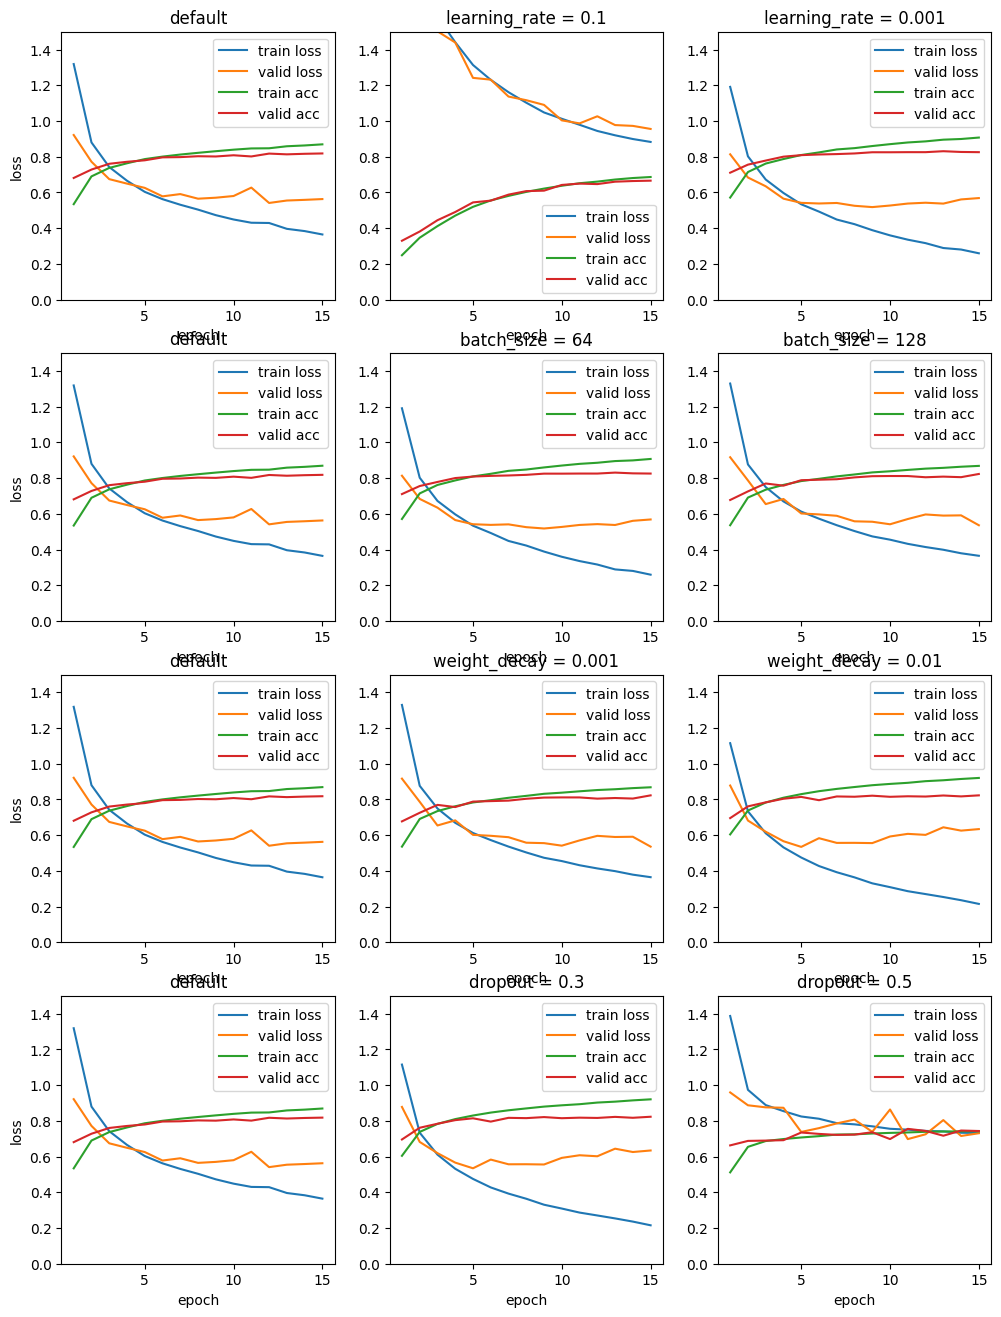

In [23]:
ts_default = 1773854727
epoch = [i+1 for i in range(15)]

fig, axs = plt.subplots(4, 3, figsize=(12, 16))
i = 0
for key, value in hyperparams.items():
    axs[i, 0].plot(
        epoch, cur[cur["timestamp"] == ts_default]["train_loss"], label="train loss"
    )
    axs[i, 0].plot(
        epoch, cur[cur["timestamp"] == ts_default]["val_loss"], label="valid loss"
    )
    axs[i, 0].plot(
        epoch, cur[cur["timestamp"] == ts_default]["train_acc"], label="train acc"
    )
    axs[i, 0].plot(
        epoch, cur[cur["timestamp"] == ts_default]["val_acc"], label="valid acc"
    )
    axs[i, 0].legend()
    axs[i, 0].set_ylim(0, 1.5)
    axs[i, 0].set_title("default")
    axs[i, 0].set_xlabel("epoch")
    axs[i, 0].set_ylabel("loss")

    axs[i, 1].plot(
        epoch, cur[cur["timestamp"] == ts[i]]["train_loss"], label="train loss"
    )
    axs[i, 1].plot(
        epoch, cur[cur["timestamp"] == ts[i]]["val_loss"], label="valid loss"
    )
    axs[i, 1].plot(
        epoch, cur[cur["timestamp"] == ts[i]]["train_acc"], label="train acc"
    )
    axs[i, 1].plot(
        epoch, cur[cur["timestamp"] == ts[i]]["val_acc"], label="valid acc"
    )
    axs[i, 1].legend()
    axs[i, 1].set_title(f"{key} = {value[0]}")
    axs[i, 1].set_ylim(0, 1.5)
    axs[i, 1].set_xlabel("epoch")

    axs[i, 2].plot(
        epoch, cur[cur["timestamp"] == ts[i + 1]]["train_loss"], label="train loss"
    )
    axs[i, 2].plot(
        epoch, cur[cur["timestamp"] == ts[i + 1]]["val_loss"], label="valid loss"
    )
    axs[i, 2].plot(
        epoch, cur[cur["timestamp"] == ts[i+1]]["train_acc"], label="train acc"
    )
    axs[i, 2].plot(
        epoch, cur[cur["timestamp"] == ts[i+1]]["val_acc"], label="valid acc"
    )
    axs[i, 2].legend()
    axs[i, 2].set_title(f"{key} = {value[1]}")
    axs[i, 2].set_ylim(0, 1.5)
    axs[i, 2].set_xlabel("epoch")
    i += 1
# axs.show_legend()
# plt.show()